# 6CS012 Final Portfolio Project 2026
# Name: Aman Shrestha
# Id: 2408222
# Part II – Vision Tasks: Jellyfish Species Classification with CNNs

**Dataset:** Jellyfish Image Dataset (6 species)  
**Task:** Multi-class Image Classification using Convolutional Neural Networks  
**Framework:** TensorFlow / Keras

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## 0. Setup & Imports

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import time
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import VGG16

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.20.0
GPU available: True


---
## 1. Data Understanding, Analysis, Visualization and Cleaning

### 1.1 Dataset Overview

The dataset contains images of **6 jellyfish species**:
- `barrel_jellyfish`
- `blue_jellyfish`
- `compass_jellyfish`
- `lions_mane_jellyfish`
- `mauve_stinger_jellyfish`
- `Moon_jellyfish`

The data is pre-split into **Train / Validation / Test** directories.

In [ ]:
DATASET_ROOT = '/content/drive/MyDrive/Ai and machine learning/assessment/archive/Train_Test_Valid'

TRAIN_DIR = os.path.join(DATASET_ROOT, 'Train')
VALID_DIR = os.path.join(DATASET_ROOT, 'valid')
TEST_DIR  = os.path.join(DATASET_ROOT, 'test')

CLASS_NAMES = sorted(os.listdir(TRAIN_DIR))
NUM_CLASSES = len(CLASS_NAMES)

IMG_SIZE    = (128, 128)   # resize target
BATCH_SIZE  = 32

print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES}")

Classes (6): ['Moon_jellyfish', 'barrel_jellyfish', 'blue_jellyfish', 'compass_jellyfish', 'lions_mane_jellyfish', 'mauve_stinger_jellyfish']


In [ ]:
# ── Count images per split per class ────────────────────────────────────────
def count_images(directory):
    counts = {}
    for cls in CLASS_NAMES:
        cls_path = os.path.join(directory, cls)
        if os.path.isdir(cls_path):
            counts[cls] = len([
                f for f in os.listdir(cls_path)
                if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))
            ])
    return counts

train_counts = count_images(TRAIN_DIR)
valid_counts = count_images(VALID_DIR)
test_counts  = count_images(TEST_DIR)

print(f"{'Class':<30} {'Train':>8} {'Valid':>8} {'Test':>8}")
print("-" * 56)
total_train = total_valid = total_test = 0
for cls in CLASS_NAMES:
    tr = train_counts.get(cls, 0)
    va = valid_counts.get(cls, 0)
    te = test_counts.get(cls,  0)
    total_train += tr; total_valid += va; total_test += te
    print(f"{cls:<30} {tr:>8} {va:>8} {te:>8}")
print("-" * 56)
print(f"{'TOTAL':<30} {total_train:>8} {total_valid:>8} {total_test:>8}")
print(f"\nGrand total images: {total_train + total_valid + total_test}")

Class                             Train    Valid     Test
--------------------------------------------------------
Moon_jellyfish                      150        6        6
barrel_jellyfish                    150        5        5
blue_jellyfish                      150        7        7
compass_jellyfish                   150        7        7
lions_mane_jellyfish                150        7        8
mauve_stinger_jellyfish             150        7        7
--------------------------------------------------------
TOTAL                               900       39       40

Grand total images: 979


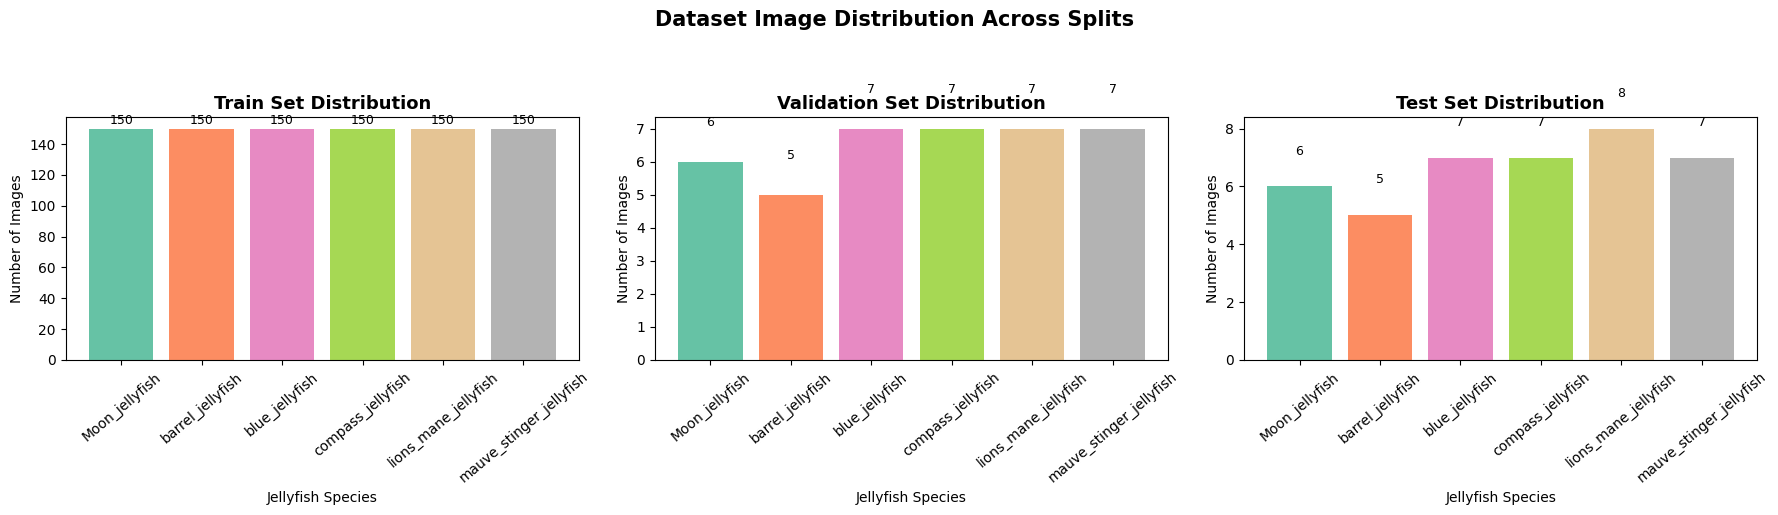

In [ ]:
# ── Visualise class distribution ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
splits     = [('Train', train_counts), ('Validation', valid_counts), ('Test', test_counts)]
colors     = plt.cm.Set2(np.linspace(0, 1, NUM_CLASSES))

for ax, (split_name, counts) in zip(axes, splits):
    bars = ax.bar(counts.keys(), counts.values(), color=colors)
    ax.set_title(f'{split_name} Set Distribution', fontsize=13, fontweight='bold')
    ax.set_xlabel('Jellyfish Species')
    ax.set_ylabel('Number of Images')
    ax.tick_params(axis='x', rotation=40)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)

plt.suptitle('Dataset Image Distribution Across Splits', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('distribution.png', bbox_inches='tight')
plt.show()

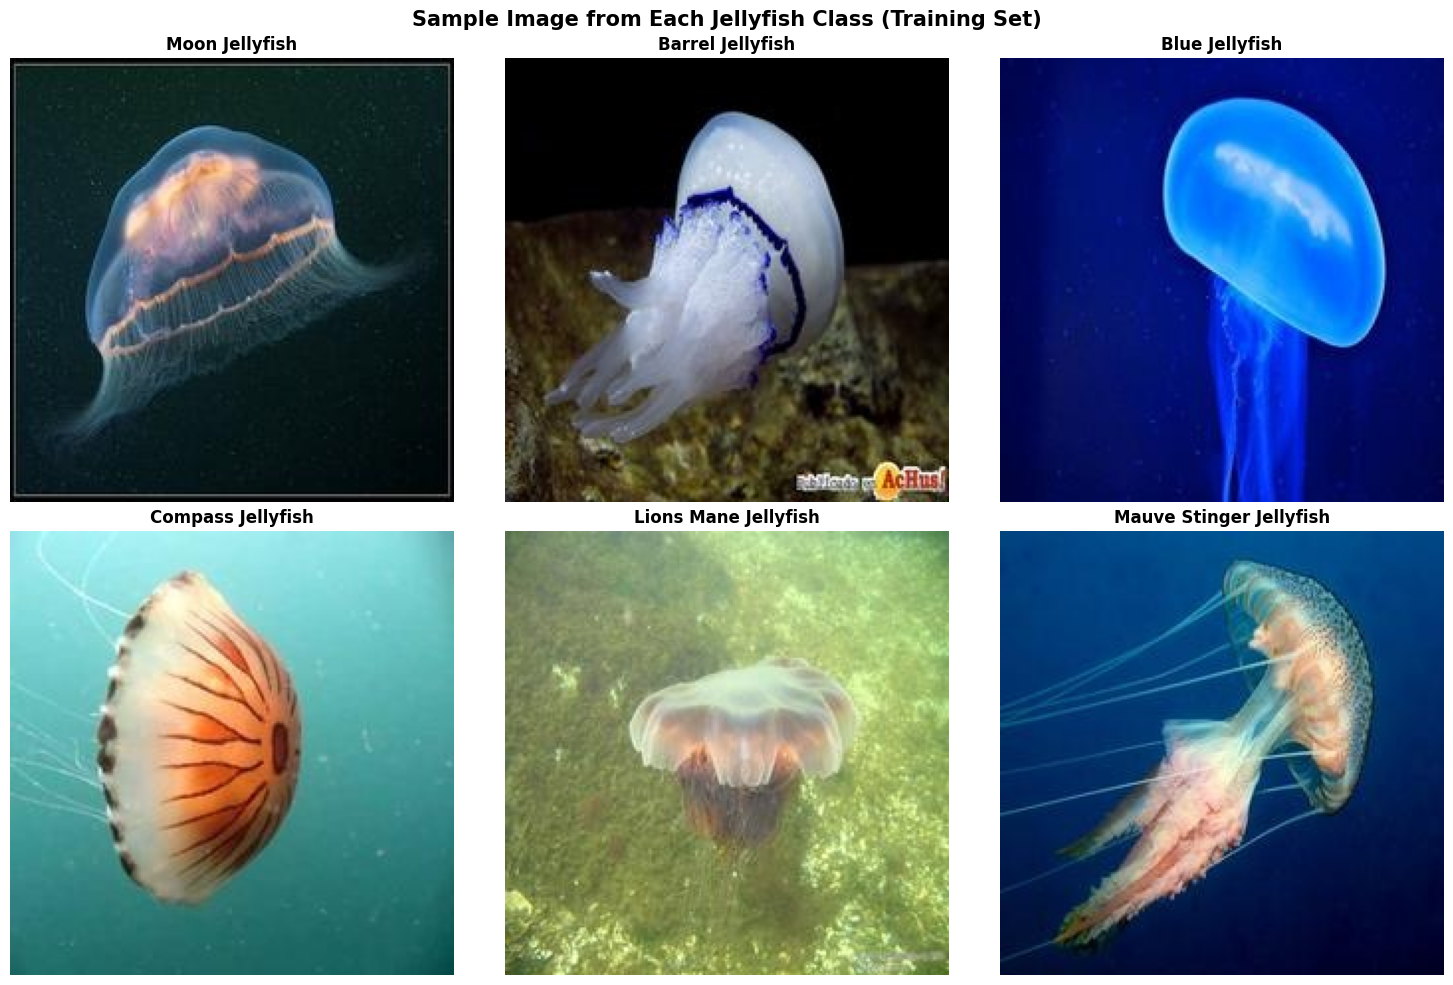

In [ ]:
# ── Visualise sample images from each class ──────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, cls in enumerate(CLASS_NAMES):
    cls_path = os.path.join(TRAIN_DIR, cls)
    img_file = os.listdir(cls_path)[0]
    img = mpimg.imread(os.path.join(cls_path, img_file))
    axes[idx].imshow(img)
    axes[idx].set_title(cls.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    axes[idx].axis('off')

plt.suptitle('Sample Image from Each Jellyfish Class (Training Set)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_images.png', bbox_inches='tight')
plt.show()

### 1.2 Preprocessing & Data Generators


In [ ]:
# ── Data generators ──────────────────────────────────────────────────────────
train_datagen = ImageDataGenerator(
    rescale=1.0/255
)

# No augmentation for validation/test — only rescale
eval_datagen = ImageDataGenerator(rescale=1.0/255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True, seed=42
)
valid_gen = eval_datagen.flow_from_directory(
    VALID_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)
test_gen = eval_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

# Map integer labels to class names for later use
CLASS_INDICES = {v: k for k, v in train_gen.class_indices.items()}
print("Class index mapping:", CLASS_INDICES)

Found 900 images belonging to 6 classes.
Found 39 images belonging to 6 classes.
Found 40 images belonging to 6 classes.
Class index mapping: {0: 'Moon_jellyfish', 1: 'barrel_jellyfish', 2: 'blue_jellyfish', 3: 'compass_jellyfish', 4: 'lions_mane_jellyfish', 5: 'mauve_stinger_jellyfish'}


Found 900 images belonging to 6 classes.


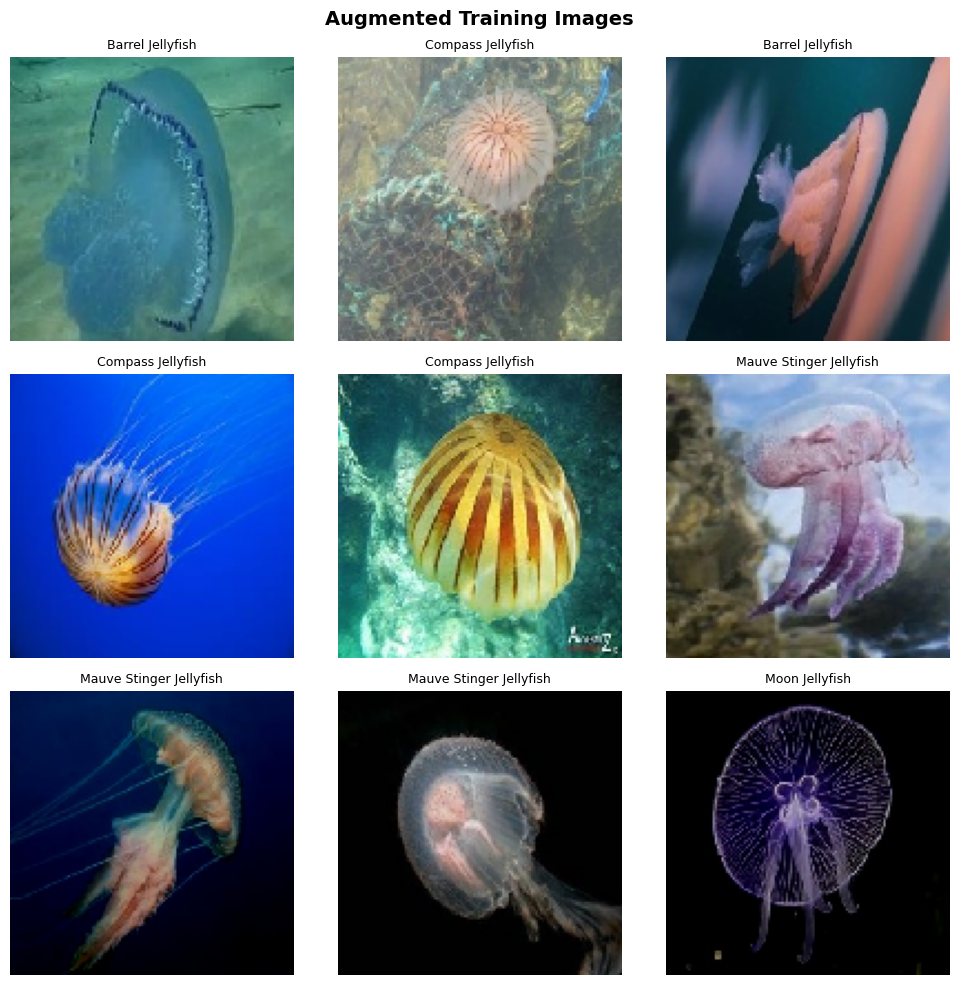

In [ ]:
# ── Visualise augmented images ────────────────────────────────────────────────
aug_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=9,
    class_mode='categorical', shuffle=True, seed=7
)
aug_imgs, aug_labels = next(aug_gen)

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(aug_imgs[i])
    ax.set_title(CLASS_INDICES[np.argmax(aug_labels[i])].replace('_', ' ').title(), fontsize=9)
    ax.axis('off')
plt.suptitle('Augmented Training Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('augmented_samples.png', bbox_inches='tight')
plt.show()

---
## 2. Part A — Design, Train and Evaluate a Baseline CNN Model

### 2.1 Baseline Model Architecture

The baseline model follows the prescribed structure:
- **3 Convolutional layers**, each followed by a MaxPooling layer
- **3 Fully Connected (Dense) layers**
- **Output layer** with Softmax activation for 6-class classification

In [ ]:
def build_baseline_model(input_shape=(128, 128, 3), num_classes=6):
    model = models.Sequential(name='Baseline_CNN')

    # ── Convolutional Block 1 ────────────────────────────────────────────────
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                            input_shape=input_shape))
    model.add(layers.MaxPooling2D((2, 2)))

    # ── Convolutional Block 2 ────────────────────────────────────────────────
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))

    # ── Convolutional Block 3 ────────────────────────────────────────────────
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))

    # ── Flatten & Fully Connected Layers ────────────────────────────────────
    model.add(layers.Flatten())
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dense(64,  activation='relu'))

    # ── Output Layer ─────────────────────────────────────────────────────────
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

baseline_model = build_baseline_model()
baseline_model.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,523,654 (32.52 MB)

 Trainable params: 8,523,654 (32.52 MB)

 Non-trainable params: 0 (0.00 B)

### 2.2 Compile and Train Baseline Model

In [ ]:
baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_baseline = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True,
                  verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    ModelCheckpoint('best_baseline.keras', monitor='val_loss',
                    save_best_only=True, verbose=1)
]

EPOCHS = 30

print("Training Baseline CNN...")
t0 = time.time()
history_baseline = baseline_model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=EPOCHS,
    callbacks=callbacks_baseline
)
baseline_time = time.time() - t0
print(f"\nBaseline training time: {baseline_time:.1f}s")

# Load best saved model
baseline_model = keras.models.load_model('best_baseline.keras')
print("Best baseline model loaded.")

Training Baseline CNN...
Epoch 1/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.2365 - loss: 1.8196
Epoch 1: val_loss improved from None to 1.58211, saving model to best_baseline.keras

Epoch 1: finished saving model to best_baseline.keras
29/29 ━━━━━━━━━━━━━━━━━━━━ 311s 11s/step - accuracy: 0.2667 - loss: 1.7555 - val_accuracy: 0.3590 - val_loss: 1.5821 - learning_rate: 0.0010
Epoch 2/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.3850 - loss: 1.5035
Epoch 2: val_loss improved from 1.58211 to 1.44264, saving model to best_baseline.keras

Epoch 2: finished saving model to best_baseline.keras
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 153ms/step - accuracy: 0.3822 - loss: 1.4977 - val_accuracy: 0.4103 - val_loss: 1.4426 - learning_rate: 0.0010
Epoch 3/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.4778 - loss: 1.2965
Epoch 3: val_loss improved from 1.44264 to 1.41462, saving model to best_baseline.keras

Epoch 3: finished saving model to best_baseline.keras
29/29 ━━━━━

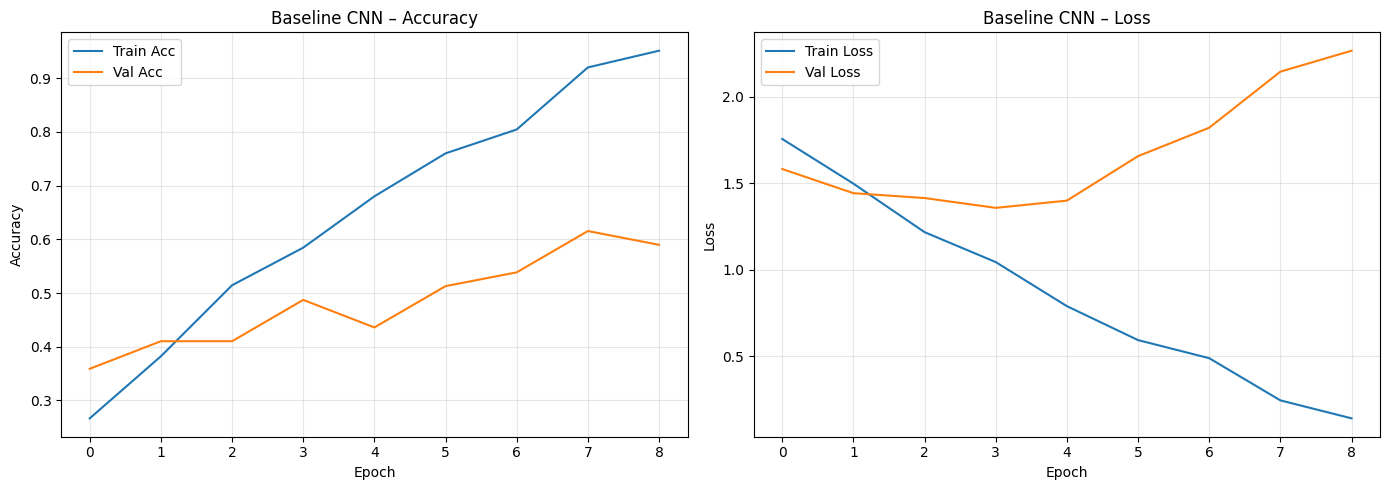

In [ ]:
# ── Plot training curves ──────────────────────────────────────────────────────
def plot_history(history, title='Model', save_name=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history.history['accuracy'],     label='Train Acc')
    axes[0].plot(history.history['val_accuracy'], label='Val Acc')
    axes[0].set_title(f'{title} – Accuracy')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history['loss'],     label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Val Loss')
    axes[1].set_title(f'{title} – Loss')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    if save_name:
        plt.savefig(save_name, bbox_inches='tight')
    plt.show()

plot_history(history_baseline, title='Baseline CNN', save_name='baseline_curves.png')

### 2.3 Evaluate Baseline Model

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 796ms/step

Baseline CNN — Test Accuracy : 57.50%
Baseline CNN — Test Loss     : 1.1263

Classification Report:
                         precision    recall  f1-score   support

         Moon_jellyfish       0.60      0.50      0.55         6
       barrel_jellyfish       0.31      0.80      0.44         5
         blue_jellyfish       1.00      0.43      0.60         7
      compass_jellyfish       0.50      0.86      0.63         7
   lions_mane_jellyfish       1.00      0.75      0.86         8
mauve_stinger_jellyfish       1.00      0.14      0.25         7

               accuracy                           0.57        40
              macro avg       0.73      0.58      0.55        40
           weighted avg       0.77      0.57      0.57        40



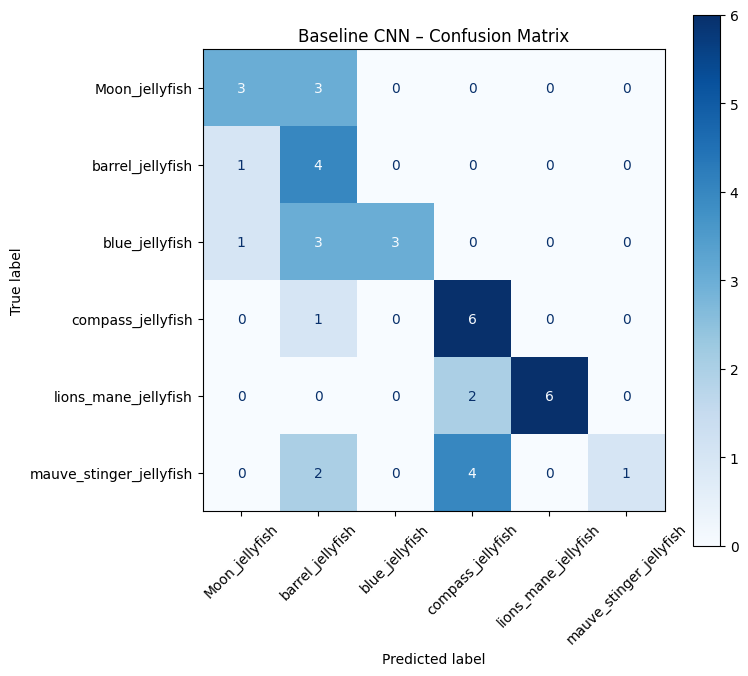

In [ ]:
def evaluate_model(model, test_gen, model_name='Model'):
    """Full evaluation: accuracy, classification report, confusion matrix."""
    test_gen.reset()
    y_pred_probs = model.predict(test_gen, verbose=1)
    y_pred       = np.argmax(y_pred_probs, axis=1)
    y_true       = test_gen.classes

    loss, acc = model.evaluate(test_gen, verbose=0)
    print(f"\n{'='*50}")
    print(f"{model_name} — Test Accuracy : {acc*100:.2f}%")
    print(f"{model_name} — Test Loss     : {loss:.4f}")
    print(f"{'='*50}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred,
                                target_names=list(CLASS_INDICES.values())))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(8, 7))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=list(CLASS_INDICES.values()))
    disp.plot(ax=ax, xticks_rotation=45, cmap='Blues')
    ax.set_title(f'{model_name} – Confusion Matrix')
    plt.tight_layout()
    plt.savefig(f'{model_name.lower().replace(" ","_")}_cm.png', bbox_inches='tight')
    plt.show()

    return acc, loss, y_pred, y_true

baseline_acc, baseline_loss, baseline_preds, y_true = evaluate_model(
    baseline_model, test_gen, 'Baseline CNN'
)

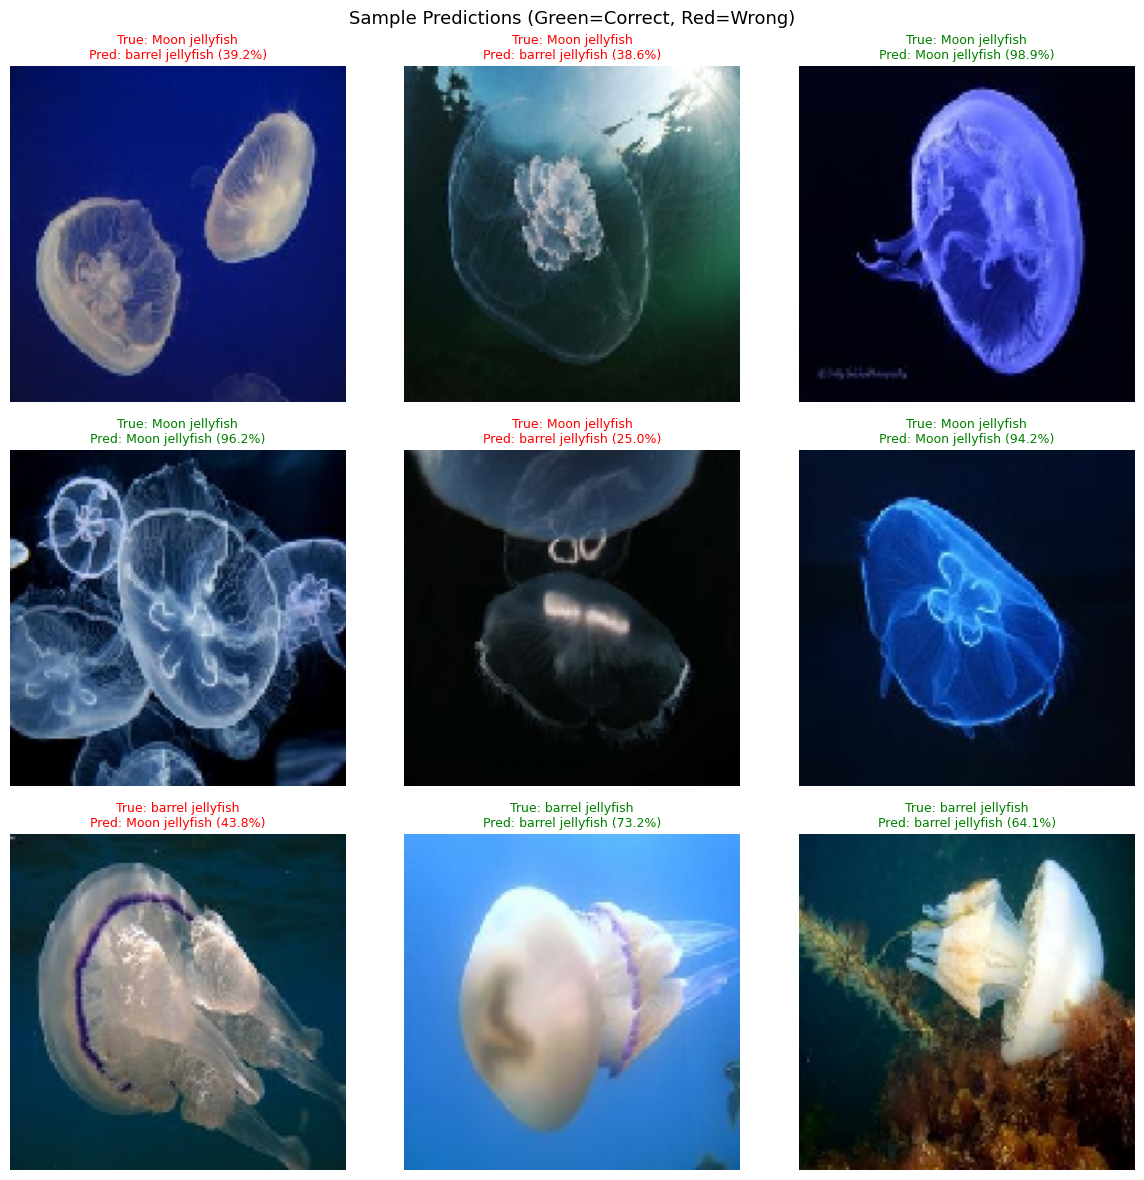

In [ ]:
# ── Inference on sample images ────────────────────────────────────────────────
def show_sample_predictions(model, test_gen, n=9):
    test_gen.reset()
    imgs, labels = next(test_gen)
    preds = model.predict(imgs[:n], verbose=0)

    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    for i, ax in enumerate(axes.flatten()):
        ax.imshow(imgs[i])
        true_cls = CLASS_INDICES[np.argmax(labels[i])]
        pred_cls = CLASS_INDICES[np.argmax(preds[i])]
        conf     = np.max(preds[i]) * 100
        color    = 'green' if true_cls == pred_cls else 'red'
        ax.set_title(f"True: {true_cls.replace('_',' ')}\n"
                     f"Pred: {pred_cls.replace('_',' ')} ({conf:.1f}%)",
                     color=color, fontsize=9)
        ax.axis('off')
    plt.suptitle('Sample Predictions (Green=Correct, Red=Wrong)', fontsize=13)
    plt.tight_layout()
    plt.savefig('sample_predictions.png', bbox_inches='tight')
    plt.show()

show_sample_predictions(baseline_model, test_gen)

---
## 3. Part A — Deeper Architecture with Regularisation

The deeper model **doubles** the number of convolutional layers (6 blocks) and adds:
- **Batch Normalisation** after each Conv layer (stabilises training, reduces internal covariate shift)
- **Dropout** in the dense layers (prevents overfitting by randomly deactivating neurons)
- More filters per layer for richer feature extraction

In [ ]:
def build_deeper_model(input_shape=(128, 128, 3), num_classes=6):
    model = models.Sequential(name='Deeper_CNN')

    # ── Block 1 ──────────────────────────────────────────────────────────────
    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same',
                            input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.25))

    # ── Block 2 ──────────────────────────────────────────────────────────────
    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.25))

    # ── Block 3 ──────────────────────────────────────────────────────────────
    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.25))

    # ── Fully Connected Layers ────────────────────────────────────────────────
    model.add(layers.Flatten())
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))

    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))

    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.3))

    # ── Output ────────────────────────────────────────────────────────────────
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

deeper_model = build_deeper_model()
deeper_model.summary()

Model: "Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │    16,777,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 17,234,598 (65.74 MB)

 Trainable params: 17,232,166 (65.74 MB)

 Non-trainable params: 2,432 (9.50 KB)

In [ ]:
# ── Train Deeper Model (Adam) ─────────────────────────────────────────────────
deeper_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_deeper = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    ModelCheckpoint('best_deeper_adam.keras', monitor='val_loss',
                    save_best_only=True, verbose=1)
]

print("Training Deeper CNN (Adam)...")
t0 = time.time()
history_deeper_adam = deeper_model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=EPOCHS,
    callbacks=callbacks_deeper
)
deeper_adam_time = time.time() - t0
print(f"\nDeeper (Adam) training time: {deeper_adam_time:.1f}s")

deeper_model = keras.models.load_model('best_deeper_adam.keras')
print("Best deeper (Adam) model loaded.")

Training Deeper CNN (Adam)...
Epoch 1/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 527ms/step - accuracy: 0.2031 - loss: 2.5814
Epoch 1: val_loss improved from None to 1.83374, saving model to best_deeper_adam.keras

Epoch 1: finished saving model to best_deeper_adam.keras
29/29 ━━━━━━━━━━━━━━━━━━━━ 38s 688ms/step - accuracy: 0.2411 - loss: 2.4273 - val_accuracy: 0.1538 - val_loss: 1.8337 - learning_rate: 0.0010
Epoch 2/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.3032 - loss: 2.0164
Epoch 2: val_loss did not improve from 1.83374
29/29 ━━━━━━━━━━━━━━━━━━━━ 12s 120ms/step - accuracy: 0.2567 - loss: 2.2210 - val_accuracy: 0.1795 - val_loss: 3.4413 - learning_rate: 0.0010
Epoch 3/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.3036 - loss: 2.0394
Epoch 3: val_loss did not improve from 1.83374
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 128ms/step - accuracy: 0.3178 - loss: 1.9688 - val_accuracy: 0.1795 - val_loss: 2.1832 - learning_rate: 0.0010
Epoch 4/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/

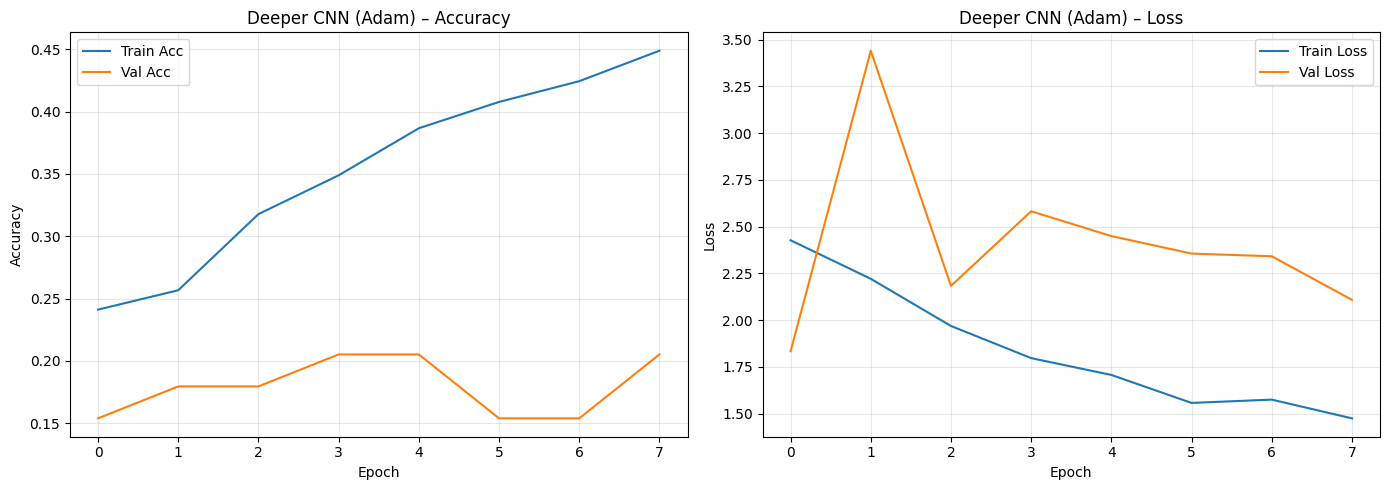

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 882ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step

Deeper CNN (Adam) — Test Accuracy : 12.50%
Deeper CNN (Adam) — Test Loss     : 1.8601

Classification Report:
                         precision    recall  f1-score   support

         Moon_jellyfish       0.00      0.00      0.00         6
       barrel_jellyfish       0.00      0.00      0.00         5
         blue_jellyfish       0.14      0.71      0.24         7
      compass_jellyfish       0.00      0.00      0.00         7
   lions_mane_jellyfish       0.00      0.00      0.00         8
mauve_stinger_jellyfish       0.00      0.00      0.00         7

               accuracy                           0.12        40
              macro avg       0.02      0.12      0.04        40
           weighted avg       0.03      0.12      0.04        40



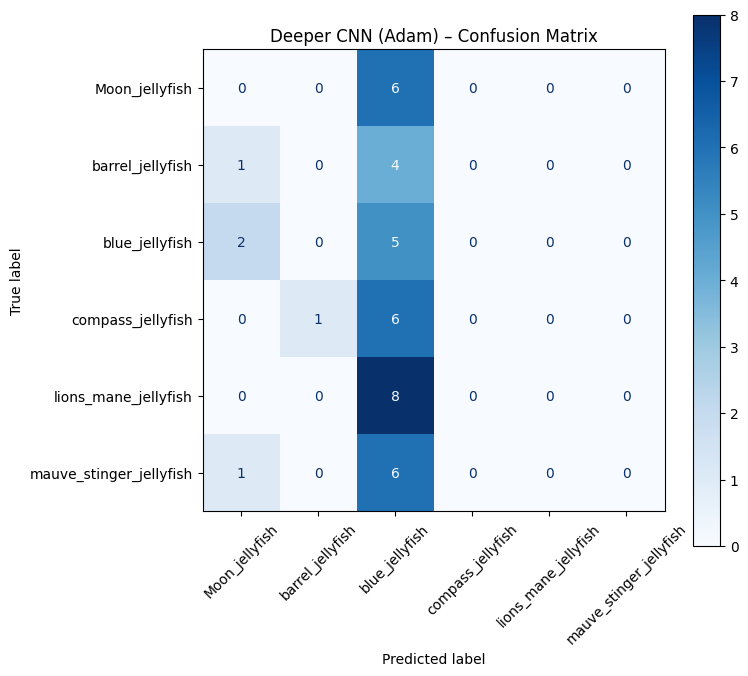

In [ ]:
plot_history(history_deeper_adam, title='Deeper CNN (Adam)',
             save_name='deeper_adam_curves.png')

deeper_adam_acc, deeper_adam_loss, _, _ = evaluate_model(
    deeper_model, test_gen, 'Deeper CNN (Adam)'
)

---
## 4. Part A — Experimentation: Optimizer Analysis (SGD vs Adam)

In [ ]:
# ── Train Deeper Model (SGD) ──────────────────────────────────────────────────
deeper_model_sgd = build_deeper_model()
deeper_model_sgd.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Training Deeper CNN (SGD)...")
t0 = time.time()
history_deeper_sgd = deeper_model_sgd.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=EPOCHS,
    callbacks=[
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3),
    ModelCheckpoint('best_deeper_sgd.keras', monitor='val_loss',
                    save_best_only=True, verbose=1)
]
)
deeper_sgd_time = time.time() - t0
print(f"\nDeeper (SGD) training time: {deeper_sgd_time:.1f}s")

deeper_model_sgd = keras.models.load_model('best_deeper_sgd.keras')
print("Best deeper (SGD) model loaded.")

Training Deeper CNN (SGD)...
Epoch 1/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step - accuracy: 0.1818 - loss: 2.7081
Epoch 1: val_loss improved from None to 615.10431, saving model to best_deeper_sgd.keras

Epoch 1: finished saving model to best_deeper_sgd.keras
29/29 ━━━━━━━━━━━━━━━━━━━━ 27s 521ms/step - accuracy: 0.2167 - loss: 2.4721 - val_accuracy: 0.1282 - val_loss: 615.1043 - learning_rate: 0.0100
Epoch 2/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.2604 - loss: 2.0438
Epoch 2: val_loss improved from 615.10431 to 61.00888, saving model to best_deeper_sgd.keras

Epoch 2: finished saving model to best_deeper_sgd.keras
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 157ms/step - accuracy: 0.2767 - loss: 2.0097 - val_accuracy: 0.1282 - val_loss: 61.0089 - learning_rate: 0.0100
Epoch 3/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.3250 - loss: 1.7835
Epoch 3: val_loss improved from 61.00888 to 22.20391, saving model to best_deeper_sgd.keras

Epoch 3: finished saving model to best

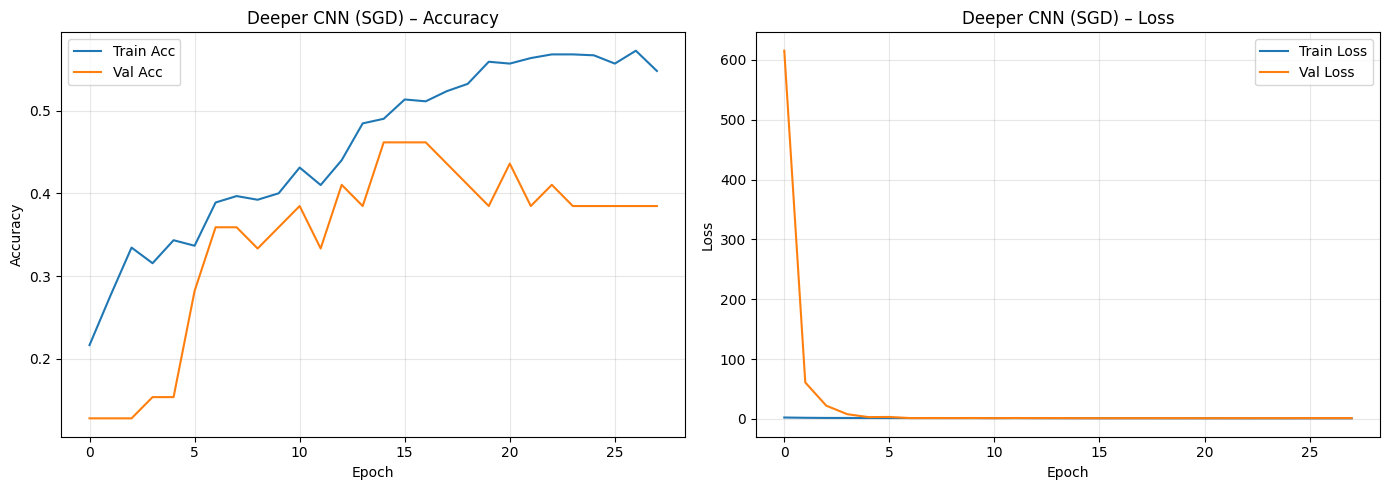

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 729ms/step

Deeper CNN (SGD) — Test Accuracy : 52.50%
Deeper CNN (SGD) — Test Loss     : 1.1191

Classification Report:
                         precision    recall  f1-score   support

         Moon_jellyfish       0.57      0.67      0.62         6
       barrel_jellyfish       0.50      0.80      0.62         5
         blue_jellyfish       0.33      0.14      0.20         7
      compass_jellyfish       0.56      0.71      0.62         7
   lions_mane_jellyfish       0.67      0.75      0.71         8
mauve_stinger_jellyfish       0.25      0.14      0.18         7

               accuracy                           0.53        40
              macro avg       0.48      0.54      0.49        40
           weighted avg       0.48      0.53      0.49        40



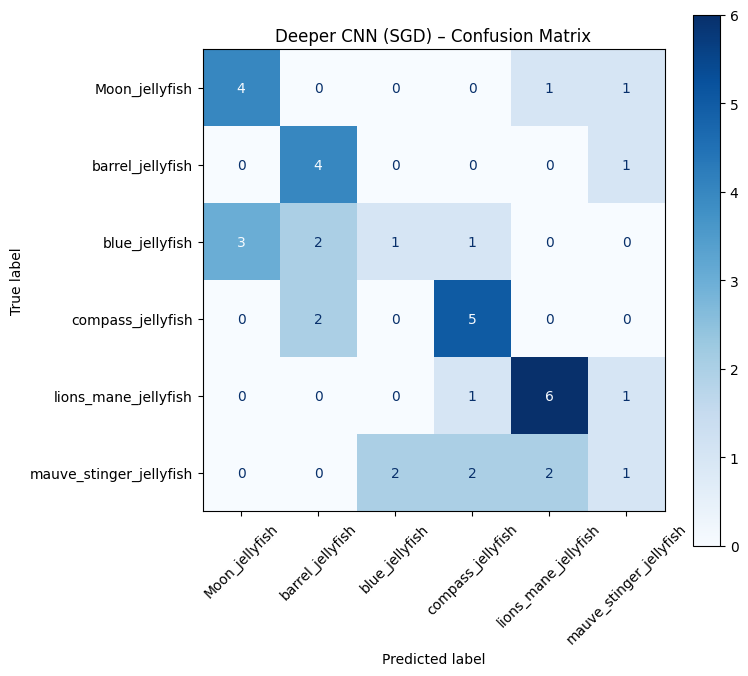

In [ ]:
plot_history(history_deeper_sgd, title='Deeper CNN (SGD)',
             save_name='deeper_sgd_curves.png')

deeper_sgd_acc, deeper_sgd_loss, _, _ = evaluate_model(
    deeper_model_sgd, test_gen, 'Deeper CNN (SGD)'
)

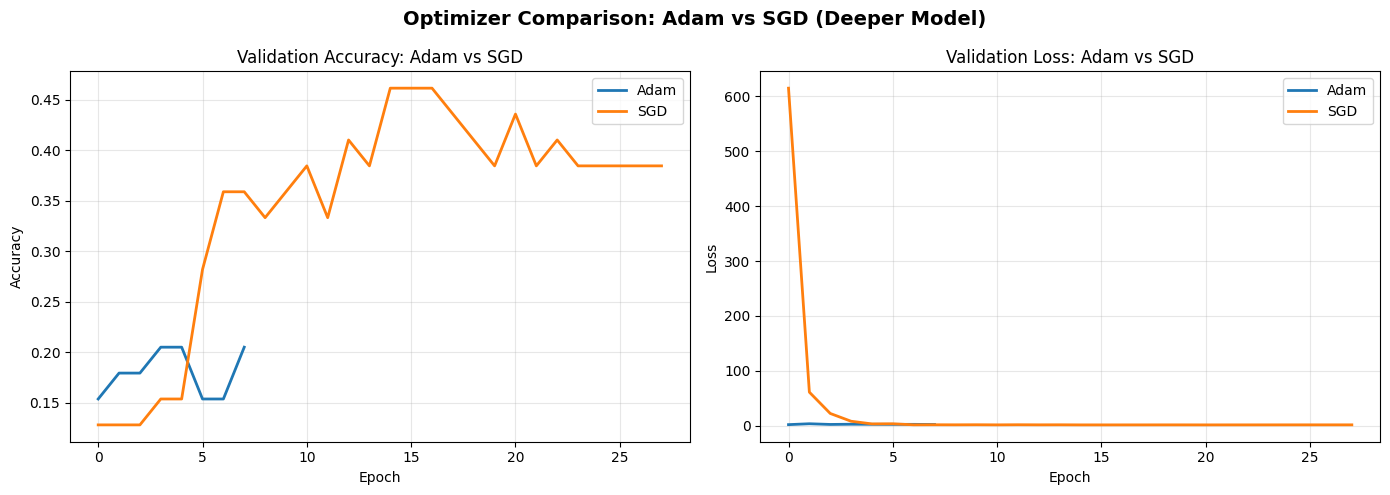

In [ ]:
# ── Overlay Adam vs SGD loss curves ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_deeper_adam.history['val_accuracy'], label='Adam', linewidth=2)
axes[0].plot(history_deeper_sgd.history['val_accuracy'],  label='SGD',  linewidth=2)
axes[0].set_title('Validation Accuracy: Adam vs SGD')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history_deeper_adam.history['val_loss'], label='Adam', linewidth=2)
axes[1].plot(history_deeper_sgd.history['val_loss'],  label='SGD',  linewidth=2)
axes[1].set_title('Validation Loss: Adam vs SGD')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Optimizer Comparison: Adam vs SGD (Deeper Model)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('optimizer_comparison.png', bbox_inches='tight')
plt.show()

---
## 5. Part A — Ablation Study

Remove **Dropout** to observe its effect on overfitting.

In [ ]:
def build_no_dropout_model(input_shape=(128, 128, 3), num_classes=6):
    """Deeper model WITHOUT Dropout — for ablation study."""
    model = models.Sequential(name='No_Dropout_CNN')

    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))

    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))

    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))

    model.add(layers.Flatten())
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dense(num_classes, activation='softmax'))
    return model

ablation_model = build_no_dropout_model()
ablation_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Training Ablation Model (No Dropout)...")
history_ablation = ablation_model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=EPOCHS,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ModelCheckpoint('no_dropout.keras', monitor='val_loss',
                        save_best_only=True, verbose=1)
    ],
    verbose=1
)

ablation_model = keras.models.load_model('no_dropout.keras')
print("Best no-dropout model loaded.")

Training Ablation Model (No Dropout)...
Epoch 1/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - accuracy: 0.2899 - loss: 5.7727
Epoch 1: val_loss improved from None to 1.90562, saving model to no_dropout.keras

Epoch 1: finished saving model to no_dropout.keras
29/29 ━━━━━━━━━━━━━━━━━━━━ 22s 432ms/step - accuracy: 0.3389 - loss: 4.3739 - val_accuracy: 0.2308 - val_loss: 1.9056
Epoch 2/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.4191 - loss: 2.8892
Epoch 2: val_loss did not improve from 1.90562
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 112ms/step - accuracy: 0.4178 - loss: 2.6713 - val_accuracy: 0.2051 - val_loss: 2.0279
Epoch 3/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.4791 - loss: 2.0644
Epoch 3: val_loss did not improve from 1.90562
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step - accuracy: 0.4956 - loss: 1.9805 - val_accuracy: 0.1538 - val_loss: 2.6967
Epoch 4/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.6169 - loss: 1.3136
Epoch 4: val_loss did not improve fr

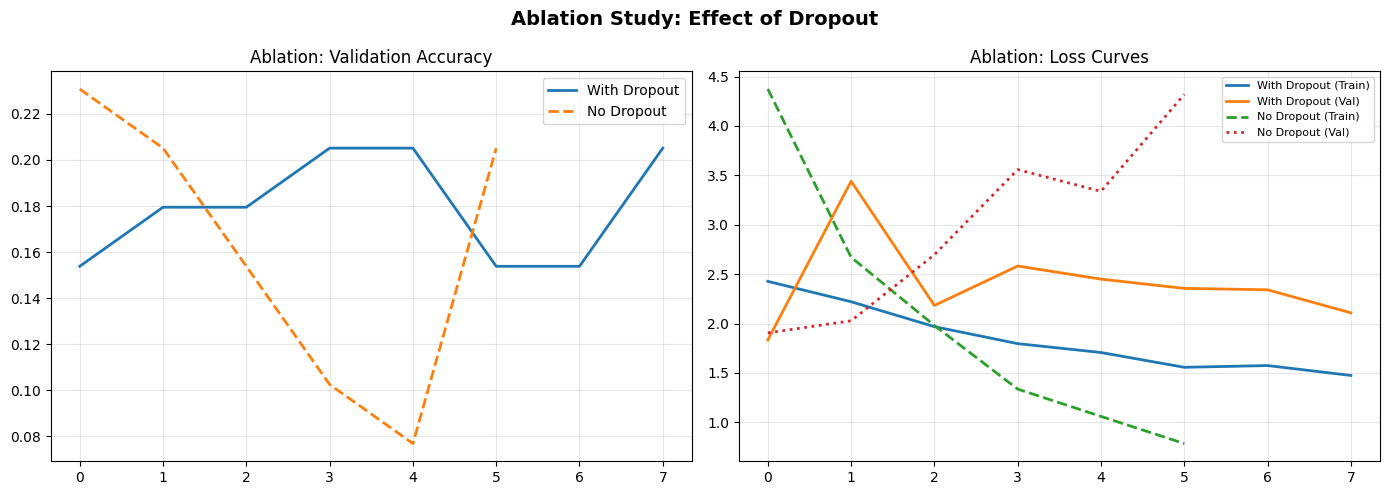

In [ ]:
# Compare Dropout vs No-Dropout
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_deeper_adam.history['val_accuracy'],  label='With Dropout', linewidth=2)
axes[0].plot(history_ablation.history['val_accuracy'], label='No Dropout',    linewidth=2, linestyle='--')
axes[0].set_title('Ablation: Validation Accuracy'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history_deeper_adam.history['train_loss'] if 'train_loss' in history_deeper_adam.history
             else history_deeper_adam.history['loss'],     label='With Dropout (Train)', linewidth=2)
axes[1].plot(history_deeper_adam.history['val_loss'],  label='With Dropout (Val)',   linewidth=2)
axes[1].plot(history_ablation.history['loss'],         label='No Dropout (Train)',   linewidth=2, linestyle='--')
axes[1].plot(history_ablation.history['val_loss'],     label='No Dropout (Val)',     linewidth=2, linestyle=':')
axes[1].set_title('Ablation: Loss Curves'); axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

plt.suptitle('Ablation Study: Effect of Dropout', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('ablation_study.png', bbox_inches='tight')
plt.show()

---
## 6. Comparative Summary (Part A)

2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 3s/step

No-Dropout (Ablation) — Test Accuracy : 27.50%
No-Dropout (Ablation) — Test Loss     : 1.8753

Classification Report:
                         precision    recall  f1-score   support

         Moon_jellyfish       0.40      0.33      0.36         6
       barrel_jellyfish       0.17      0.80      0.28         5
         blue_jellyfish       0.00      0.00      0.00         7
      compass_jellyfish       0.00      0.00      0.00         7
   lions_mane_jellyfish       0.57      0.50      0.53         8
mauve_stinger_jellyfish       0.33      0.14      0.20         7

               accuracy                           0.28        40
              macro avg       0.25      0.30      0.23        40
           weighted avg       0.25      0.28      0.23        40



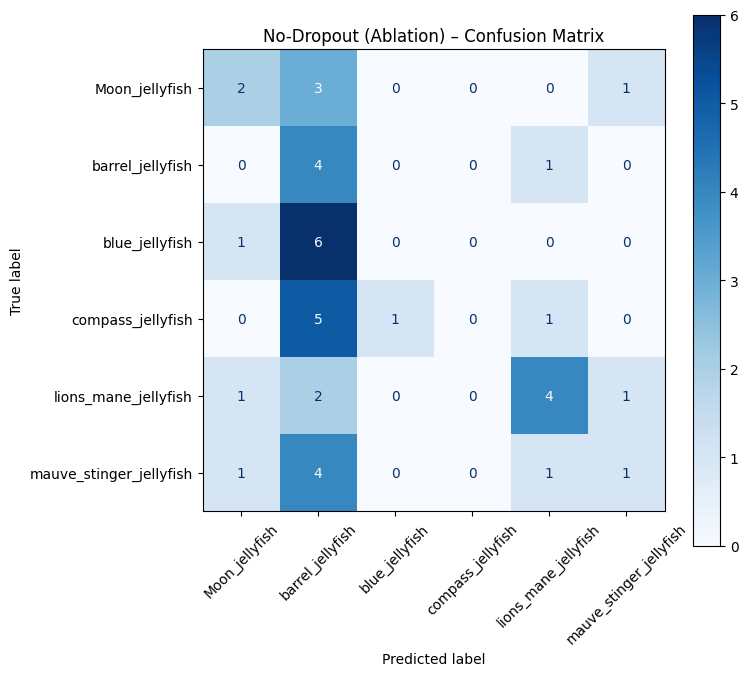


Model                            Test Acc  Test Loss   Train Time
Baseline CNN                       57.50%     1.1263         364s
Deeper CNN (Adam)                  12.50%     1.8601          73s
Deeper CNN (SGD)                   52.50%     1.1191         137s
No-Dropout (Ablation)              27.50%     1.8753          N/A


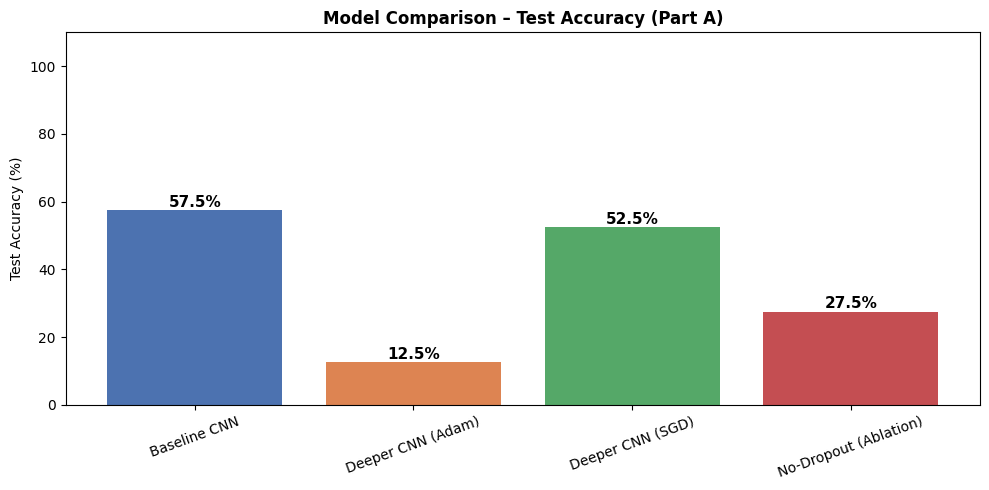

In [ ]:
# Evaluate all Part A models
ablation_acc, ablation_loss, _, _ = evaluate_model(ablation_model, test_gen, 'No-Dropout (Ablation)')

# Summary table
results = {
    'Baseline CNN':      {'acc': baseline_acc,    'loss': baseline_loss,    'time': baseline_time},
    'Deeper CNN (Adam)': {'acc': deeper_adam_acc, 'loss': deeper_adam_loss, 'time': deeper_adam_time},
    'Deeper CNN (SGD)':  {'acc': deeper_sgd_acc,  'loss': deeper_sgd_loss,  'time': deeper_sgd_time},
    'No-Dropout (Ablation)': {'acc': ablation_acc,    'loss': ablation_loss,    'time': None},
}

print(f"\n{'='*65}")
print(f"{'Model':<30} {'Test Acc':>10} {'Test Loss':>10} {'Train Time':>12}")
print(f"{'='*65}")
for name, vals in results.items():
    t_str = f"{vals['time']:.0f}s" if vals['time'] else 'N/A'
    print(f"{name:<30} {vals['acc']*100:>9.2f}% {vals['loss']:>10.4f} {t_str:>12}")
print(f"{'='*65}")

# Bar chart comparison
fig, ax = plt.subplots(figsize=(10, 5))
model_names = list(results.keys())
accs = [results[n]['acc']*100 for n in model_names]
bars = ax.bar(model_names, accs, color=['#4C72B0','#DD8452','#55A868', '#C44E52'])
ax.set_ylim(0, 110)
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Model Comparison – Test Accuracy (Part A)', fontweight='bold')
ax.tick_params(axis='x', rotation=20)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{acc:.1f}%', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison_partA.png', bbox_inches='tight')
plt.show()

---
## 7. Part B — Fine-Tuning a Pre-Trained Model (Transfer Learning)

We use **MobileNetV2** pre-trained on ImageNet. It is lightweight and effective for smaller datasets.

**Strategy:**  
1. Load MobileNetV2 with frozen weights (Feature Extraction).  
2. Add custom classification head for 6 classes.  
3. Fine-tune: unfreeze top layers and retrain at a low learning rate.

In [ ]:
# ── ImageNet requires 224×224 ─────────────────────────────────────────────────
IMG_SIZE_TL   = (224, 224)

train_gen_tl = ImageDataGenerator(
    rescale=1.0/255
).flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE_TL, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True, seed=42
)

valid_gen_tl = ImageDataGenerator(rescale=1.0/255).flow_from_directory(
    VALID_DIR, target_size=IMG_SIZE_TL, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)
test_gen_tl = ImageDataGenerator(rescale=1.0/255).flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE_TL, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

Found 900 images belonging to 6 classes.
Found 39 images belonging to 6 classes.
Found 40 images belonging to 6 classes.


In [ ]:
# ── Phase 1: Feature Extraction (frozen base) ─────────────────────────────────
base_model = VGG16(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False   # freeze all base layers

# Add custom classification head
inputs = keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

tl_model = keras.Model(inputs, outputs, name='VGG16_Transfer')
tl_model.summary()

tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Phase 1 — Feature Extraction (frozen base)...")
history_tl_phase1 = tl_model.fit(
    train_gen_tl, validation_data=valid_gen_tl,
    epochs=15,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
               ModelCheckpoint('best_vgg16_phase1.keras', monitor='val_loss',
                        save_best_only=True, verbose=1)  ]
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "VGG16_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,879,686 (56.76 MB)

 Trainable params: 164,998 (644.52 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Phase 1 — Feature Extraction (frozen base)...
Epoch 1/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - accuracy: 0.1789 - loss: 1.8925
Epoch 1: val_loss improved from None to 1.68534, saving model to best_vgg16_phase1.keras

Epoch 1: finished saving model to best_vgg16_phase1.keras
29/29 ━━━━━━━━━━━━━━━━━━━━ 35s 687ms/step - accuracy: 0.2044 - loss: 1.8211 - val_accuracy: 0.2564 - val_loss: 1.6853
Epoch 2/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.3195 - loss: 1.6754
Epoch 2: val_loss improved from 1.68534 to 1.52005, saving model to best_vgg16_phase1.keras

Epoch 2: finished saving model to best_vgg16_phase1.keras
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 195ms/step - accuracy: 0.3544 - loss: 1.6303 - val_accuracy: 0.3846 - val_loss: 1.5201
Epoch 3/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.4610 - loss: 1.4414
Epoch 3: val_loss improved from 1.52005 to 1.32809, saving model to best_vgg16_phase1.keras

Epoch 3: finished saving model to best_vgg16_phase1.keras
29/29 ━━━━━

In [ ]:
# ── Phase 2: Fine-Tuning (unfreeze top layers) ────────────────────────────────
base_model.trainable = True

# Only fine-tune the last 30 layers
for layer in base_model.layers[:-4]:
    layer.trainable = False

tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),   # very low LR
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Phase 2 — Fine-Tuning (top 30 layers unfrozen)...")
t0 = time.time()
history_tl_phase2 = tl_model.fit(
    train_gen_tl, validation_data=valid_gen_tl,
    epochs=20,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3),
        ModelCheckpoint('best_vgg16_phase2.keras', monitor='val_loss',
                        save_best_only=True, verbose=1)
    ]
)
tl_time = time.time() - t0
print(f"\nTransfer Learning training time: {tl_time:.1f}s")

tl_model = keras.models.load_model('best_vgg16_phase2.keras')
print("Best VGG16 model loaded.")

Phase 2 — Fine-Tuning (top 30 layers unfrozen)...
Epoch 1/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - accuracy: 0.7774 - loss: 0.6774
Epoch 1: val_loss improved from None to 1.07998, saving model to best_vgg16_phase2.keras

Epoch 1: finished saving model to best_vgg16_phase2.keras
29/29 ━━━━━━━━━━━━━━━━━━━━ 19s 426ms/step - accuracy: 0.7922 - loss: 0.6229 - val_accuracy: 0.6154 - val_loss: 1.0800 - learning_rate: 1.0000e-05
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - accuracy: 0.8367 - loss: 0.4800
Epoch 2: val_loss did not improve from 1.07998
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 220ms/step - accuracy: 0.8511 - loss: 0.4698 - val_accuracy: 0.6667 - val_loss: 1.1200 - learning_rate: 1.0000e-05
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.8811 - loss: 0.3868
Epoch 3: val_loss did not improve from 1.07998
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 211ms/step - accuracy: 0.8833 - loss: 0.3853 - val_accuracy: 0.6410 - val_loss: 1.1627 - learning_rate: 1.0000e-05
Epoch 4/20
29/

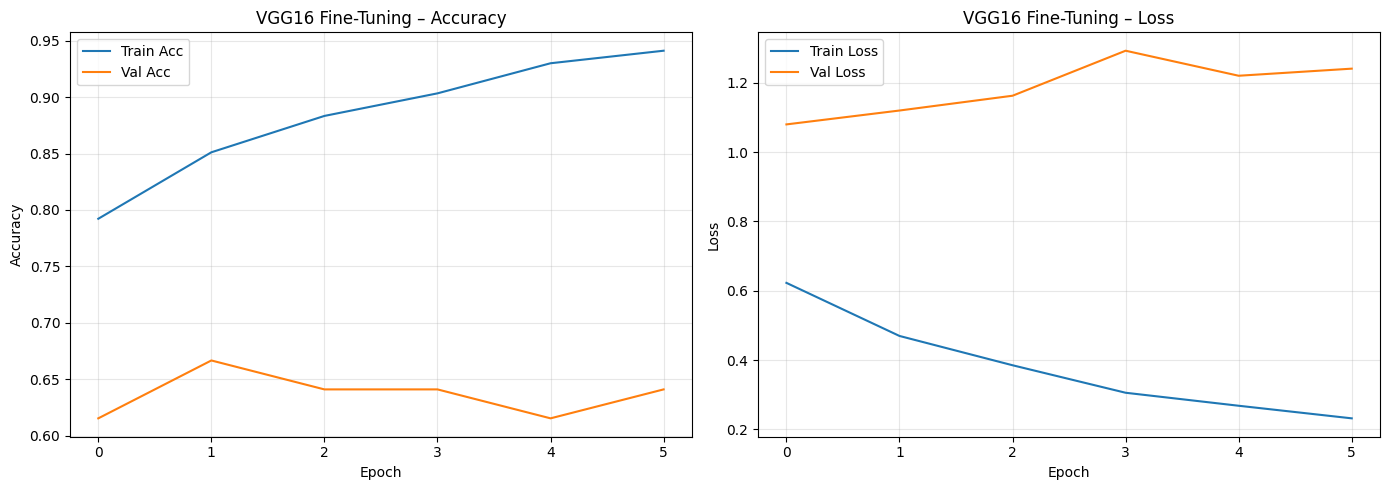

2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 5s/step

VGG16 (Transfer Learning) — Test Accuracy : 87.50%
VGG16 (Transfer Learning) — Test Loss     : 0.5027

Classification Report:
                         precision    recall  f1-score   support

         Moon_jellyfish       0.71      0.83      0.77         6
       barrel_jellyfish       0.83      1.00      0.91         5
         blue_jellyfish       0.80      0.57      0.67         7
      compass_jellyfish       0.88      1.00      0.93         7
   lions_mane_jellyfish       1.00      0.88      0.93         8
mauve_stinger_jellyfish       1.00      1.00      1.00         7

               accuracy                           0.88        40
              macro avg       0.87      0.88      0.87        40
           weighted avg       0.88      0.88      0.87        40



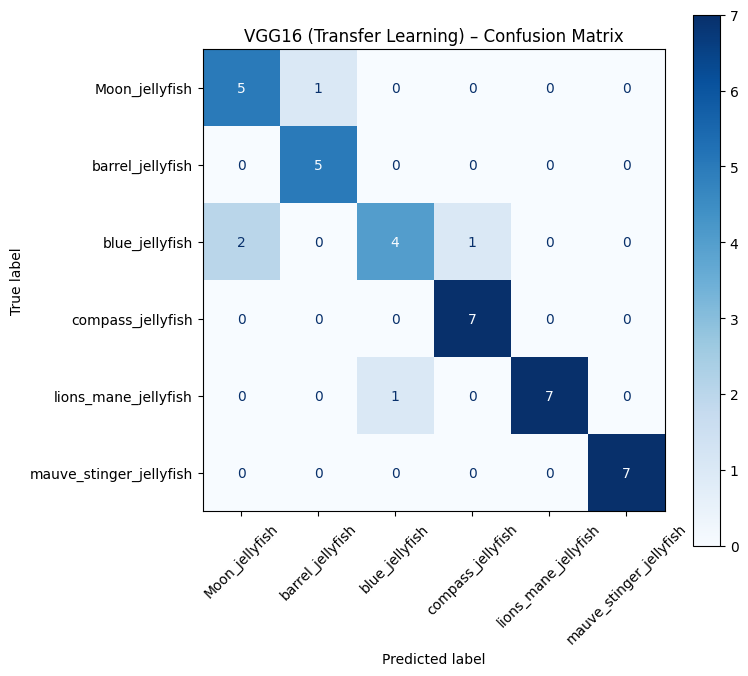

In [ ]:
plot_history(history_tl_phase2, title='VGG16 Fine-Tuning', save_name='tl_curves.png')

tl_acc, tl_loss, _, _ = evaluate_model(tl_model, test_gen_tl, 'VGG16 (Transfer Learning)')

---
## 8. Final Comparison — All Models

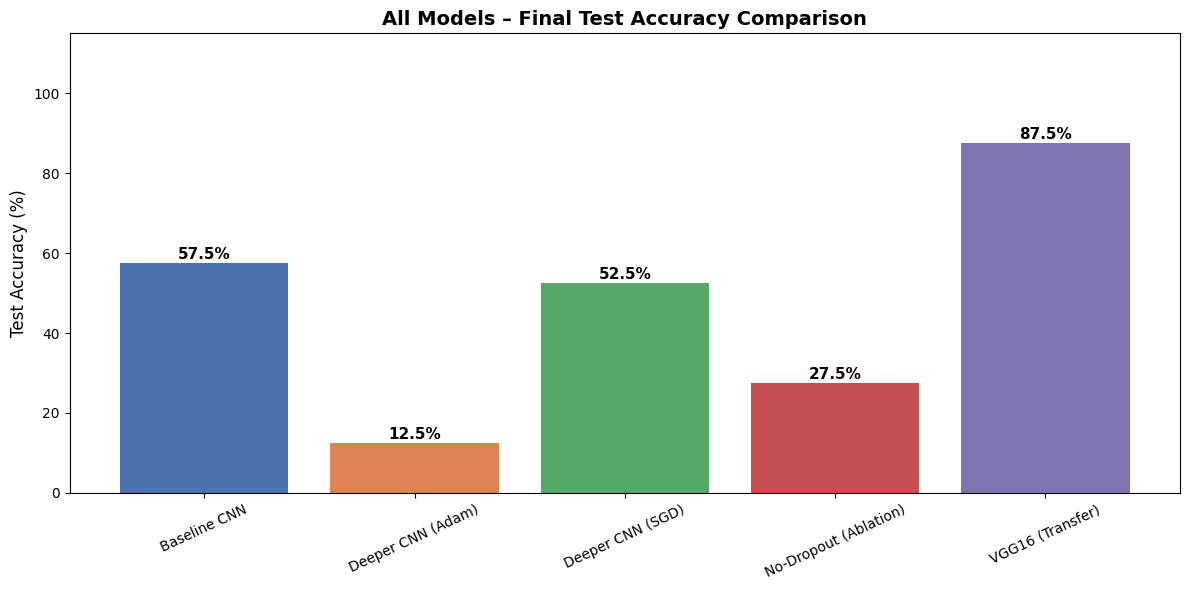


Final Model Accuracy Summary:
  Baseline CNN                        57.50%
  Deeper CNN (Adam)                   12.50%
  Deeper CNN (SGD)                    52.50%
  No-Dropout (Ablation)               27.50%
  VGG16 (Transfer)                    87.50%


In [ ]:
all_results = {
    'Baseline CNN':           baseline_acc,
    'Deeper CNN (Adam)':      deeper_adam_acc,
    'Deeper CNN (SGD)':       deeper_sgd_acc,
    'No-Dropout (Ablation)':  ablation_acc,
    'VGG16 (Transfer)':       tl_acc,
}

fig, ax = plt.subplots(figsize=(12, 6))
colors  = ['#4C72B0','#DD8452','#55A868', '#C44E52','#8172B2']
bars    = ax.bar(all_results.keys(), [v*100 for v in all_results.values()], color=colors)
ax.set_ylim(0, 115)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('All Models – Final Test Accuracy Comparison', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=25)
for bar, (name, acc) in zip(bars, all_results.items()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{acc*100:.1f}%', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('final_comparison.png', bbox_inches='tight')
plt.show()

print("\nFinal Model Accuracy Summary:")
for name, acc in all_results.items():
    print(f"  {name:<35} {acc*100:.2f}%")